In [1]:
from langgraph.graph import StateGraph,  START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

## loading variable

In [2]:
load_dotenv()  # Load environment variables from .env file

True

## define LLM

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2, max_output_tokens=512)

## define state

In [4]:
class  BlogState(TypedDict):
    topic: str
    outline: str
    blog_content: str

## define nodes

In [5]:
def create_outline(state: BlogState) -> BlogState:
    topic = state.get("topic")
    prompt = f"Create a detailed outline for a blog post about '{topic}'."
    outline = model.invoke(prompt)
    state["outline"] = outline.content
    return state

In [6]:
def create_blog_content(state: BlogState) -> BlogState:
    outline = state.get("outline")
    prompt = f"Write a blog post based on the following outline:\n{outline}"
    blog_content = model.invoke(prompt)
    state["blog_content"] = blog_content.content
    return state

## define and compile graph

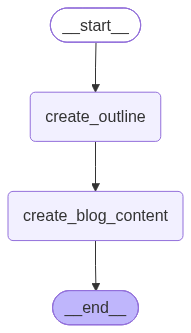

In [7]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog_content", create_blog_content)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog_content")
graph.add_edge("create_blog_content", END)

flow = graph.compile()

flow

## run with example input

In [8]:
result = flow.invoke({"topic": "Benefits of Morning Walks"})
result

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'topic': 'Benefits of Morning Walks',
 'outline': "Okay, here's a detailed outline for a blog post about the benefits of morning walks, designed",
 'blog_content': '## Rise and Thrive: The Unexpected Power of Your Morning Walk\n\nDo you ever hit snooze'}